# NB02 — Exploratory Data Analysis, Hypothesis Testing & Feature Engineering

**Full data analysis pipeline (HOURLY + DAILY)** before any ML modelling:

| Phase | What |
|-------|------|
| §1 | Load & inspect **both** master_daily and master_hourly |
| §2 | Data quality audit — missing values, duplicates, dtypes |
| §3 | Descriptive statistics per city |
| §4 | Distribution analysis — histograms, boxplots |
| §4h | **Hourly patterns** — diurnal cycles, hourly fire distributions |
| §5 | Correlation analysis — heatmaps, multicollinearity |
| §6 | Hypothesis testing — fire-day vs non-fire-day (Welch's t-test) |
| §7 | Seasonal decomposition & time-series patterns |
| §8 | Outlier detection (IQR-based) & data cleaning |
| §9 | Feature engineering — FWI, lag, rolling, Prophet, calendar |
| §9h | **Hourly feature engineering** — hour-derived daily features |
| §10 | Save **both** engineered_daily and engineered_hourly |

**Input:** `data/processed/master_daily.parquet` + `data/processed/master_hourly.parquet`  
**Output:** `data/processed/engineered_daily.parquet` + `data/processed/engineered_hourly.parquet`

In [35]:
# ─── Cell 1: Imports ──────────────────────────────────────────────────────
import subprocess, sys
for _p in ["pandas","numpy","matplotlib","seaborn","scipy","statsmodels","prophet","tqdm"]:
    try: __import__(_p)
    except ImportError: subprocess.check_call([sys.executable,"-m","pip","install","-q",_p])

import os, warnings, pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

# ── Project root ──────────────────────────────────────────────────────────
def _detect_root():
    if os.environ.get("ARIAN_ROOT"):
        return Path(os.environ["ARIAN_ROOT"]).resolve()
    here = Path.cwd().resolve()
    for c in [here, *here.parents]:
        if (c/"data").is_dir() and (c/"notebooks").is_dir(): return c
    return here.parent if here.name=="notebooks" else here

ROOT      = _detect_root()
PROCESSED = ROOT / "data" / "processed"
OUTPUTS   = ROOT / "outputs"
MODELS    = ROOT / "models"
for p in (OUTPUTS, MODELS): p.mkdir(parents=True, exist_ok=True)
print(f"Root: {ROOT}")

Root: /home/manheim666/Desktop/WildFire-Prediction


In [36]:
# ─── §1: Load BOTH master datasets ────────────────────────────────────────
df = pd.read_parquet(PROCESSED / "master_daily.parquet")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["City", "Date"]).reset_index(drop=True)

hourly_path = PROCESSED / "master_hourly.parquet"
if hourly_path.exists():
    df_h = pd.read_parquet(hourly_path)
    df_h["Timestamp"] = pd.to_datetime(df_h["Timestamp"])
    df_h["Date"] = pd.to_datetime(df_h["Date"])
    df_h = df_h.sort_values(["City", "Timestamp"]).reset_index(drop=True)
    HAS_HOURLY = True
else:
    HAS_HOURLY = False
    print("⚠ master_hourly.parquet not found — hourly analysis will be skipped")

print(f"{'─'*30} DAILY {'─'*30}")
print(f"Shape: {df.shape}")
print(f"Cities: {df['City'].nunique()}")
print(f"Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Fire rate: {df['Fire_Occurred'].mean()*100:.2f}%")

if HAS_HOURLY:
    print(f"\n{'─'*30} HOURLY {'─'*29}")
    print(f"Shape: {df_h.shape}")
    print(f"Time range: {df_h['Timestamp'].min()} → {df_h['Timestamp'].max()}")
    print(f"Fire rate: {df_h['Fire_Occurred'].mean()*100:.2f}%")
    print(f"Hours per day: {df_h.groupby(['City','Date']).size().median():.0f}")

print()
df.head(3)

────────────────────────────── DAILY ──────────────────────────────
Shape: (83472, 42)
Cities: 16
Date range: 2012-01-19 → 2026-05-01
Fire rate: 8.07%

────────────────────────────── HOURLY ─────────────────────────────
Shape: (2002944, 32)
Time range: 2012-01-19 20:00:00 → 2026-05-01 19:00:00
Fire rate: 8.08%
Hours per day: 24



,City,Date,Temperature_C_mean,Temperature_C_min,Temperature_C_max,Humidity_percent_mean,Humidity_percent_min,Humidity_percent_max,Rain_mm_sum,Wind_Speed_kmh_mean,Wind_Speed_kmh_min,Wind_Speed_kmh_max,Wind_Dir_deg_mean,Pressure_hPa_mean,Pressure_hPa_min,Pressure_hPa_max,Solar_Radiation_Wm2_mean,Soil_Temp_C_mean,Soil_Temp_C_min,Soil_Temp_C_max,Soil_Moisture_mean,Soil_Moisture_min,Soil_Moisture_max,fire_count,mean_brightness,max_frp,Fire_Occurred,Burned_Area_hectares,NDBI,NDVI,EVI,Latitude,Longitude,Elevation,Slope,Trees_pct,Urban_pct,Pop_Total,Year,Month,DayOfYear,DayOfWeek
0,Baku,2012-01-19,3.961500,3.874,4.024,81.971840,81.076523,83.458992,0.4,38.260612,35.654541,40.603470,348.176086,1015.713989,1015.090027,1016.188171,0.000000,4.774000,4.624,4.924,0.244750,0.242,0.248,0.0,0.0,0.0,0,0.0,-0.156666,0.050332,0.118743,40.4093,49.8671,24.0,0.405136,1.950468,34.169409,2.048268e+06,2012,1,19,3
1,Baku,2012-01-20,2.924000,2.124,3.924,83.210190,79.108711,88.847961,11.4,47.359066,41.904060,51.751171,350.033234,1016.340271,1014.388733,1019.156799,28.041666,4.086500,3.174,4.874,0.314125,0.250,0.368,0.0,0.0,0.0,0,0.0,-0.156666,0.050332,0.118743,40.4093,49.8671,24.0,0.405136,1.950468,34.169409,2.048268e+06,2012,1,20,4
2,Baku,2012-01-21,1.913583,1.024,2.624,73.228828,70.361877,79.368141,1.5,25.123995,8.089993,43.274933,114.667534,1021.189636,1019.156799,1022.447266,59.000000,3.009417,1.474,5.224,0.349708,0.333,0.366,0.0,0.0,0.0,0,0.0,-0.156666,0.050332,0.118743,40.4093,49.8671,24.0,0.405136,1.950468,34.169409,2.048268e+06,2012,1,21,5


In [37]:
# ─── §2: Data quality audit ───────────────────────────────────────────────
print("=" * 60)
print("DATA QUALITY AUDIT")
print("=" * 60)

# 2a. Missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality = pd.DataFrame({"Missing": missing, "Missing_%": missing_pct,
                         "Dtype": df.dtypes})
quality = quality[quality["Missing"] > 0]
if quality.empty:
    print("\nNo missing values found!")
else:
    print("\nColumns with missing values:")
    print(quality.to_string())

# 2b. Duplicates
dupes = df.duplicated(subset=["City","Date"]).sum()
print(f"\nDuplicate City-Date rows: {dupes}")
if dupes > 0:
    df = df.drop_duplicates(subset=["City","Date"], keep="last")
    print(f"  Removed duplicates → {df.shape}")

# 2c. Missing values per city
print("\nMissing values per city (sum across all columns):")
city_missing = df.groupby("City").apply(lambda g: g.isnull().sum().sum())
print(city_missing.sort_values(ascending=False).to_string())

# 2d. Data types summary
print(f"\nNumeric columns: {df.select_dtypes(include='number').shape[1]}")
print(f"Object columns:  {df.select_dtypes(include='object').shape[1]}")
print(f"Datetime columns:{df.select_dtypes(include='datetime').shape[1]}")

DATA QUALITY AUDIT

No missing values found!

Duplicate City-Date rows: 0

Missing values per city (sum across all columns):
City
Baku           0
Barda          0
Gabala         0
Ganja          0
Jalilabad      0
Khachmaz       0
Lankaran       0
Mingachevir    0
Nakhchivan     0
Quba           0
Shabran        0
Shaki          0
Shamakhi       0
Shirvan        0
Yevlakh        0
Zaqatala       0

Numeric columns: 40
Object columns:  1
Datetime columns:1


In [38]:
# ─── §3: Descriptive statistics per city ──────────────────────────────────
# Key weather columns for analysis
WEATHER_COLS = [c for c in df.columns if any(k in c for k in
    ["Temperature","Humidity","Rain","Wind_Speed","Pressure",
     "Solar","Soil_Temp","Soil_Moisture"]) and pd.api.types.is_numeric_dtype(df[c])]

print(f"Weather columns for analysis: {len(WEATHER_COLS)}")
print(f"  {WEATHER_COLS[:5]} ...")

# Per-city descriptive stats
city_profiles = []
for city in df["City"].unique():
    g = df[df["City"]==city][WEATHER_COLS]
    row = {"City": city, "n_rows": len(g)}
    for col in WEATHER_COLS:
        row[f"{col}_mean"]     = g[col].mean()
        row[f"{col}_std"]      = g[col].std()
        row[f"{col}_median"]   = g[col].median()
        row[f"{col}_skew"]     = g[col].skew()
        row[f"{col}_kurtosis"] = g[col].kurtosis()
    city_profiles.append(row)

profiles_df = pd.DataFrame(city_profiles)
profiles_df.to_csv(OUTPUTS / "city_profiles.csv", index=False)
print(f"City profiles saved: {profiles_df.shape}")

# Show summary for one representative column
print("\nTemperature_C_mean statistics per city:")
if "Temperature_C_mean" in df.columns:
    print(df.groupby("City")["Temperature_C_mean"].describe().round(2).to_string())

Weather columns for analysis: 20
  ['Temperature_C_mean', 'Temperature_C_min', 'Temperature_C_max', 'Humidity_percent_mean', 'Humidity_percent_min'] ...
City profiles saved: (16, 102)

Temperature_C_mean statistics per city:
              count   mean    std    min   25%    50%    75%    max
City                                                               
Baku         5217.0  15.46   8.33  -3.98  7.85  14.86  23.21  32.99
Barda        5217.0  16.35   9.63  -9.35  7.88  16.05  25.26  34.71
Gabala       5217.0  11.05   8.65 -16.98  3.87  11.24  18.39  28.50
Ganja        5217.0  13.91   8.96 -11.00  6.01  13.86  21.95  32.91
Jalilabad    5217.0  14.81   8.54  -8.33  7.51  14.80  22.74  31.48
Khachmaz     5217.0  14.16   8.95 -10.63  6.16  13.64  22.34  33.47
Lankaran     5217.0  16.17   7.83  -2.80  9.09  15.98  23.47  31.18
Mingachevir  5217.0  16.46   9.45  -7.32  8.10  16.06  25.19  34.75
Nakhchivan   5217.0  14.32  10.41 -11.22  5.18  14.60  23.91  33.63
Quba         5217.0  11.20 

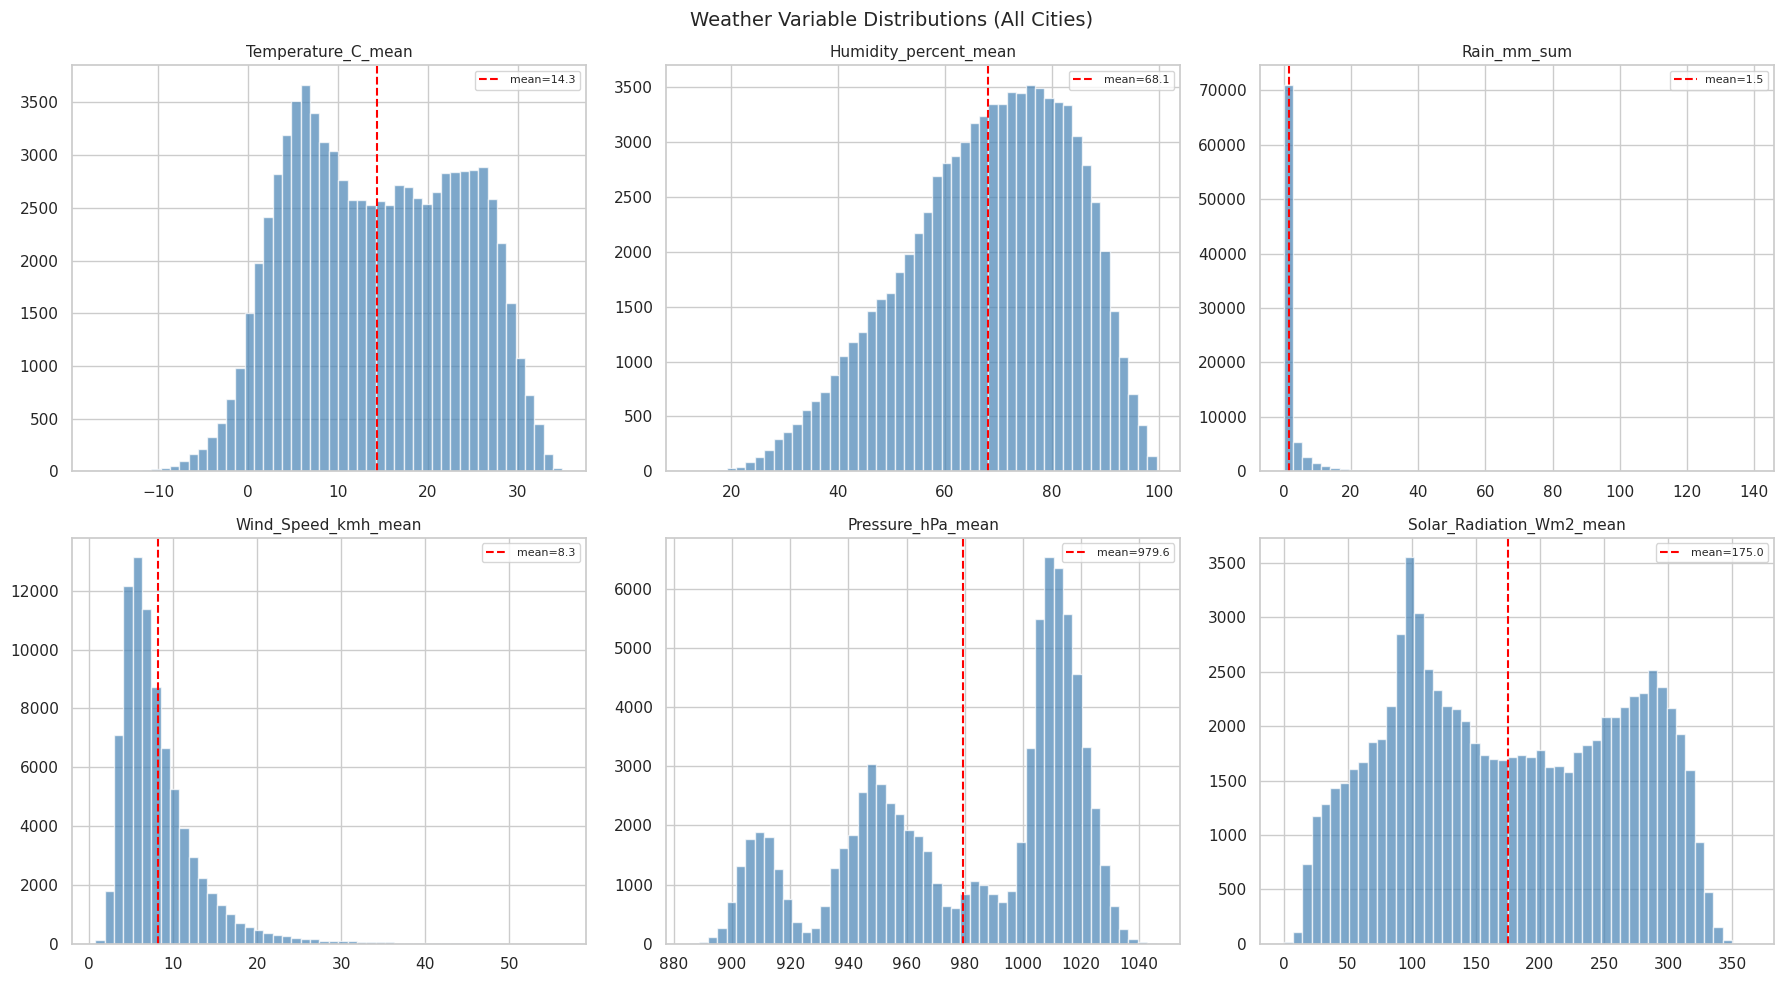

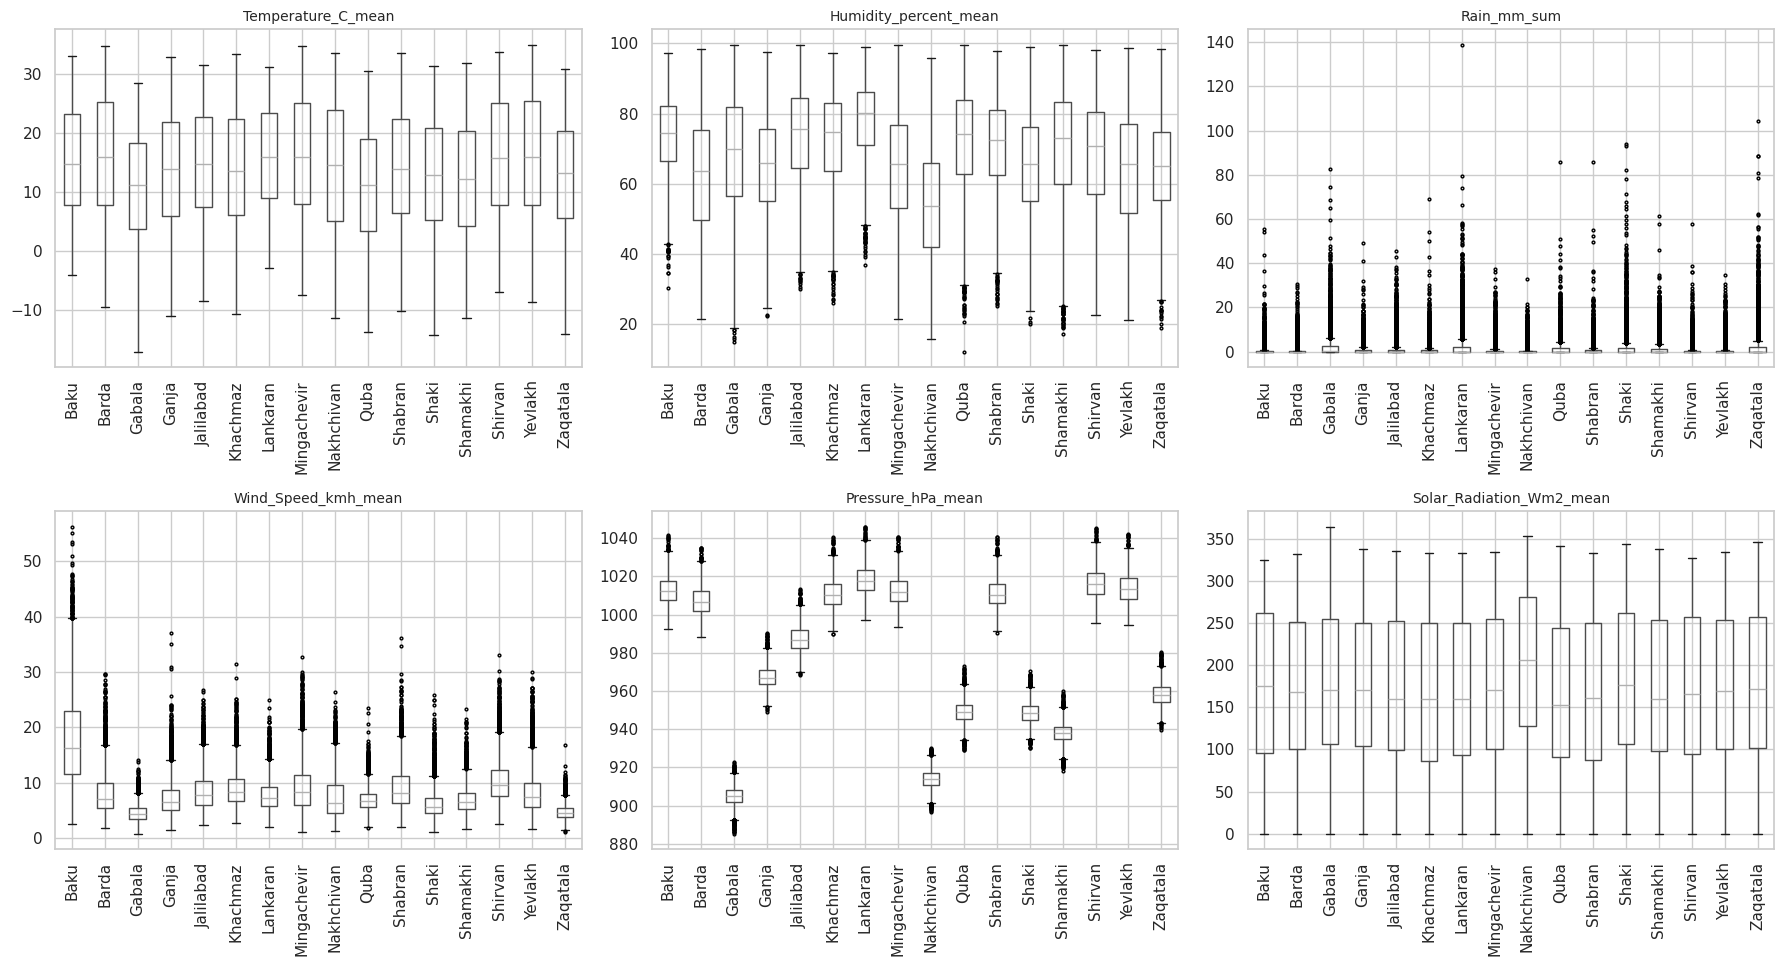

Distribution plots saved.


In [39]:
# ─── §4: Distribution analysis — histograms & boxplots ────────────────────
# 4a. Histograms for key weather variables
plot_vars = [c for c in ["Temperature_C_mean","Humidity_percent_mean",
              "Rain_mm_sum","Wind_Speed_kmh_mean","Pressure_hPa_mean",
              "Solar_Radiation_Wm2_mean"] if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Weather Variable Distributions (All Cities)", fontsize=14)
for ax, col in zip(axes.flat, plot_vars):
    df[col].hist(bins=50, ax=ax, alpha=0.7, color="steelblue", edgecolor="white")
    ax.set_title(col, fontsize=11)
    ax.axvline(df[col].mean(), color="red", linestyle="--", label=f"mean={df[col].mean():.1f}")
    ax.legend(fontsize=8)
for ax in axes.flat[len(plot_vars):]:
    ax.set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUTS / "distributions_histograms.png", dpi=150)
plt.show()

# 4b. Boxplots per city
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Weather Variables by City — Boxplots", fontsize=14)
for ax, col in zip(axes.flat, plot_vars):
    df.boxplot(column=col, by="City", ax=ax, rot=90, flierprops={"markersize": 2})
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
for ax in axes.flat[len(plot_vars):]:
    ax.set_visible(False)
plt.suptitle("")
plt.tight_layout()
plt.savefig(OUTPUTS / "distributions_boxplots.png", dpi=150)
plt.show()
print("Distribution plots saved.")

HOURLY PATTERN ANALYSIS


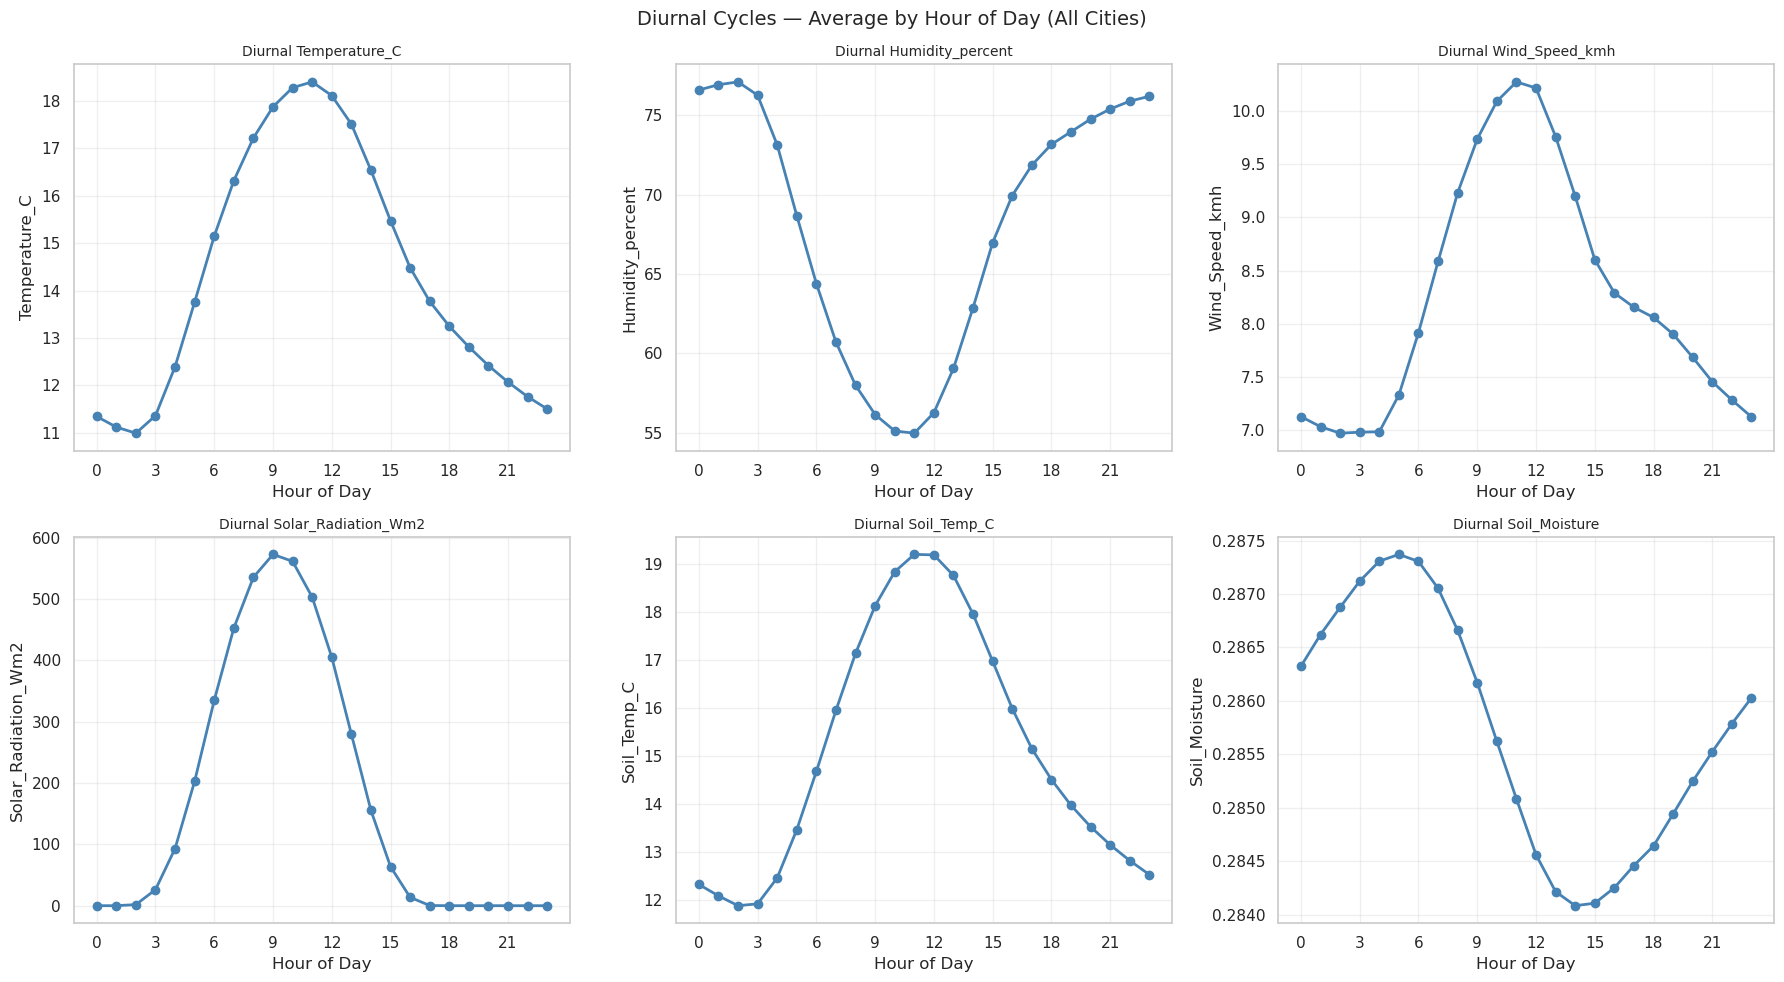

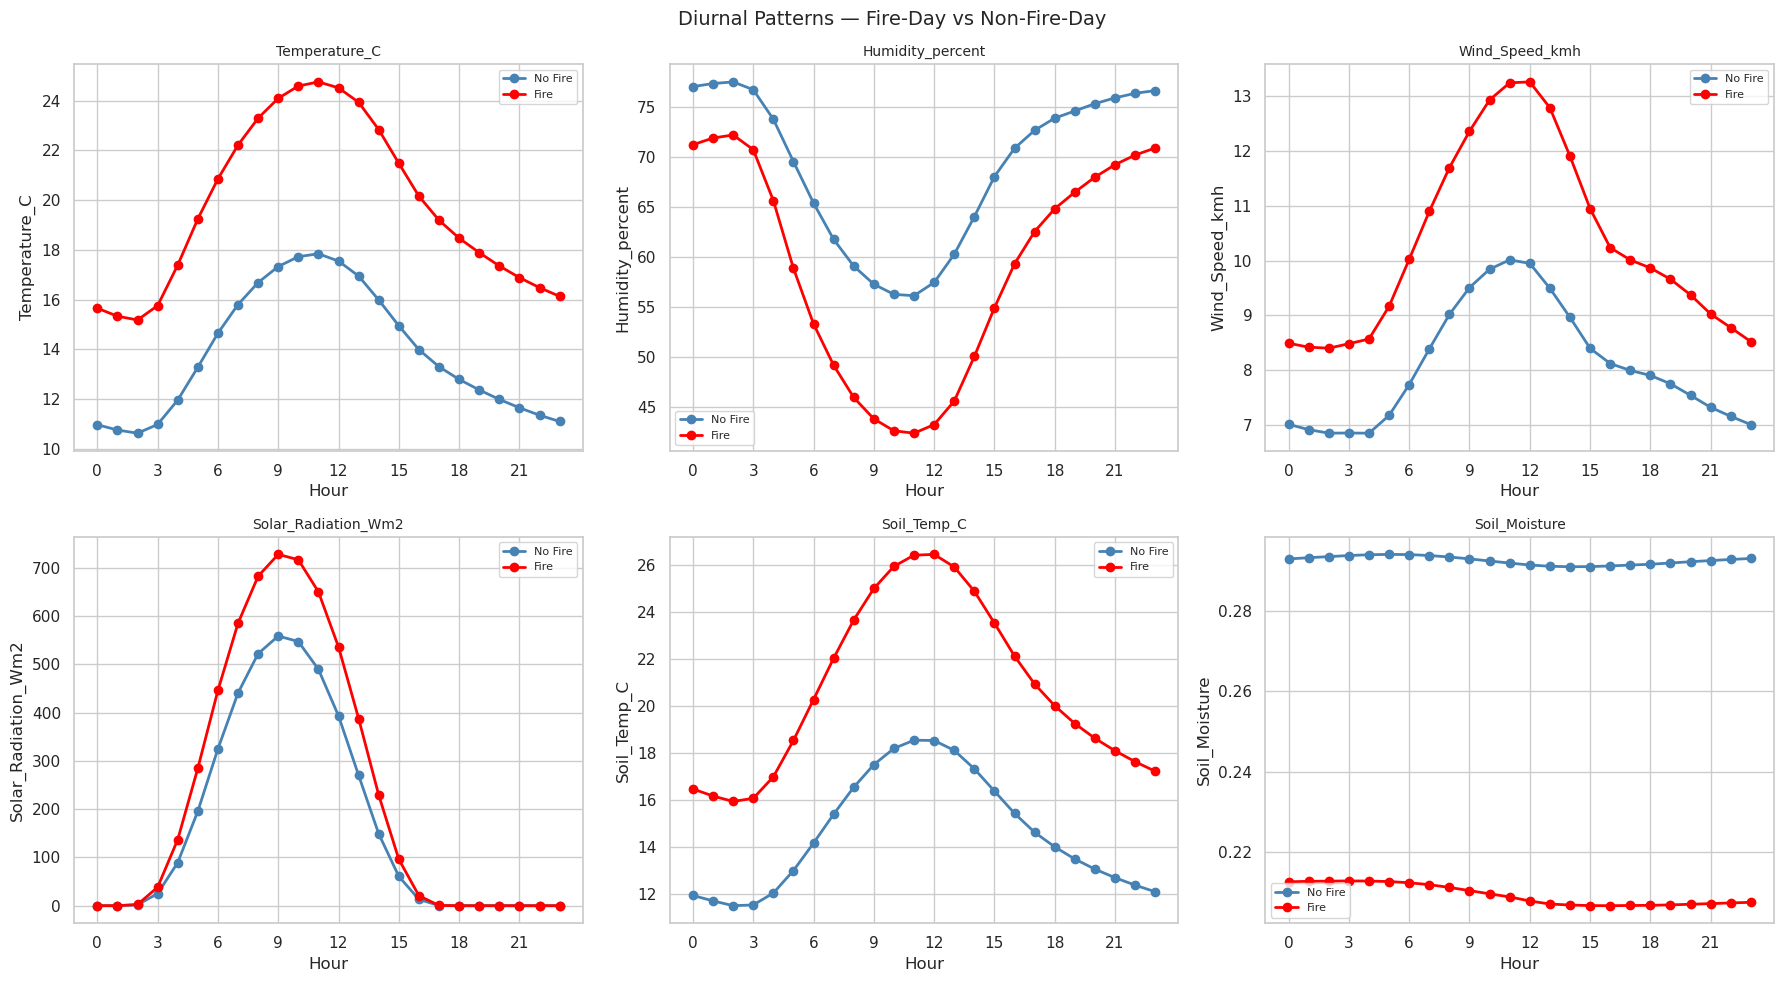


Hourly weather columns: 7
Hours in dataset: 2,002,944
Avg Temperature by hour (Baku):
  00:00 → 13.5°C
  06:00 → 16.6°C
  12:00 → 17.7°C
  18:00 → 14.5°C
Hourly pattern analysis complete.


In [40]:
# ─── §4h: Hourly patterns — diurnal cycles & fire-hour analysis ──────────
if HAS_HOURLY:
    print("=" * 60)
    print("HOURLY PATTERN ANALYSIS")
    print("=" * 60)

    HOURLY_WEATHER = [c for c in df_h.columns if any(k in c for k in
        ["Temperature_C", "Humidity_percent", "Rain_mm", "Wind_Speed_kmh",
         "Solar_Radiation", "Soil_Temp", "Soil_Moisture"])
        and pd.api.types.is_numeric_dtype(df_h[c])]

    # 4h-a. Diurnal temperature cycle (average by hour)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("Diurnal Cycles — Average by Hour of Day (All Cities)", fontsize=14)
    plot_h_vars = [c for c in ["Temperature_C", "Humidity_percent",
                    "Wind_Speed_kmh", "Solar_Radiation_Wm2",
                    "Soil_Temp_C", "Soil_Moisture"] if c in df_h.columns]
    for ax, var in zip(axes.flat, plot_h_vars):
        hourly_avg = df_h.groupby("Hour")[var].mean()
        ax.plot(hourly_avg.index, hourly_avg.values, "o-", color="steelblue", lw=2)
        ax.set_xlabel("Hour of Day")
        ax.set_ylabel(var)
        ax.set_title(f"Diurnal {var}", fontsize=10)
        ax.set_xticks(range(0, 24, 3))
        ax.grid(True, alpha=0.3)
    for ax in axes.flat[len(plot_h_vars):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.savefig(OUTPUTS / "diurnal_cycles.png", dpi=150)
    plt.show()

    # 4h-b. Fire-day vs non-fire-day diurnal patterns
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("Diurnal Patterns — Fire-Day vs Non-Fire-Day", fontsize=14)
    for ax, var in zip(axes.flat, plot_h_vars):
        fire_h = df_h[df_h["Fire_Occurred"] == 1].groupby("Hour")[var].mean()
        nofire_h = df_h[df_h["Fire_Occurred"] == 0].groupby("Hour")[var].mean()
        ax.plot(nofire_h.index, nofire_h.values, "o-", color="steelblue",
                label="No Fire", lw=2)
        ax.plot(fire_h.index, fire_h.values, "o-", color="red",
                label="Fire", lw=2)
        ax.set_xlabel("Hour")
        ax.set_ylabel(var)
        ax.set_title(var, fontsize=10)
        ax.legend(fontsize=8)
        ax.set_xticks(range(0, 24, 3))
    for ax in axes.flat[len(plot_h_vars):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.savefig(OUTPUTS / "diurnal_fire_vs_nofire.png", dpi=150)
    plt.show()

    # 4h-c. Hourly stats summary
    print(f"\nHourly weather columns: {len(HOURLY_WEATHER)}")
    print(f"Hours in dataset: {len(df_h):,}")
    print(f"Avg Temperature by hour (Baku):")
    if "Temperature_C" in df_h.columns:
        baku_h = df_h[df_h["City"] == "Baku"].groupby("Hour")["Temperature_C"].mean()
        for hr in [0, 6, 12, 18]:
            if hr in baku_h.index:
                print(f"  {hr:02d}:00 → {baku_h[hr]:.1f}°C")
    print("Hourly pattern analysis complete.")
else:
    print("Skipping hourly analysis — no hourly data available")

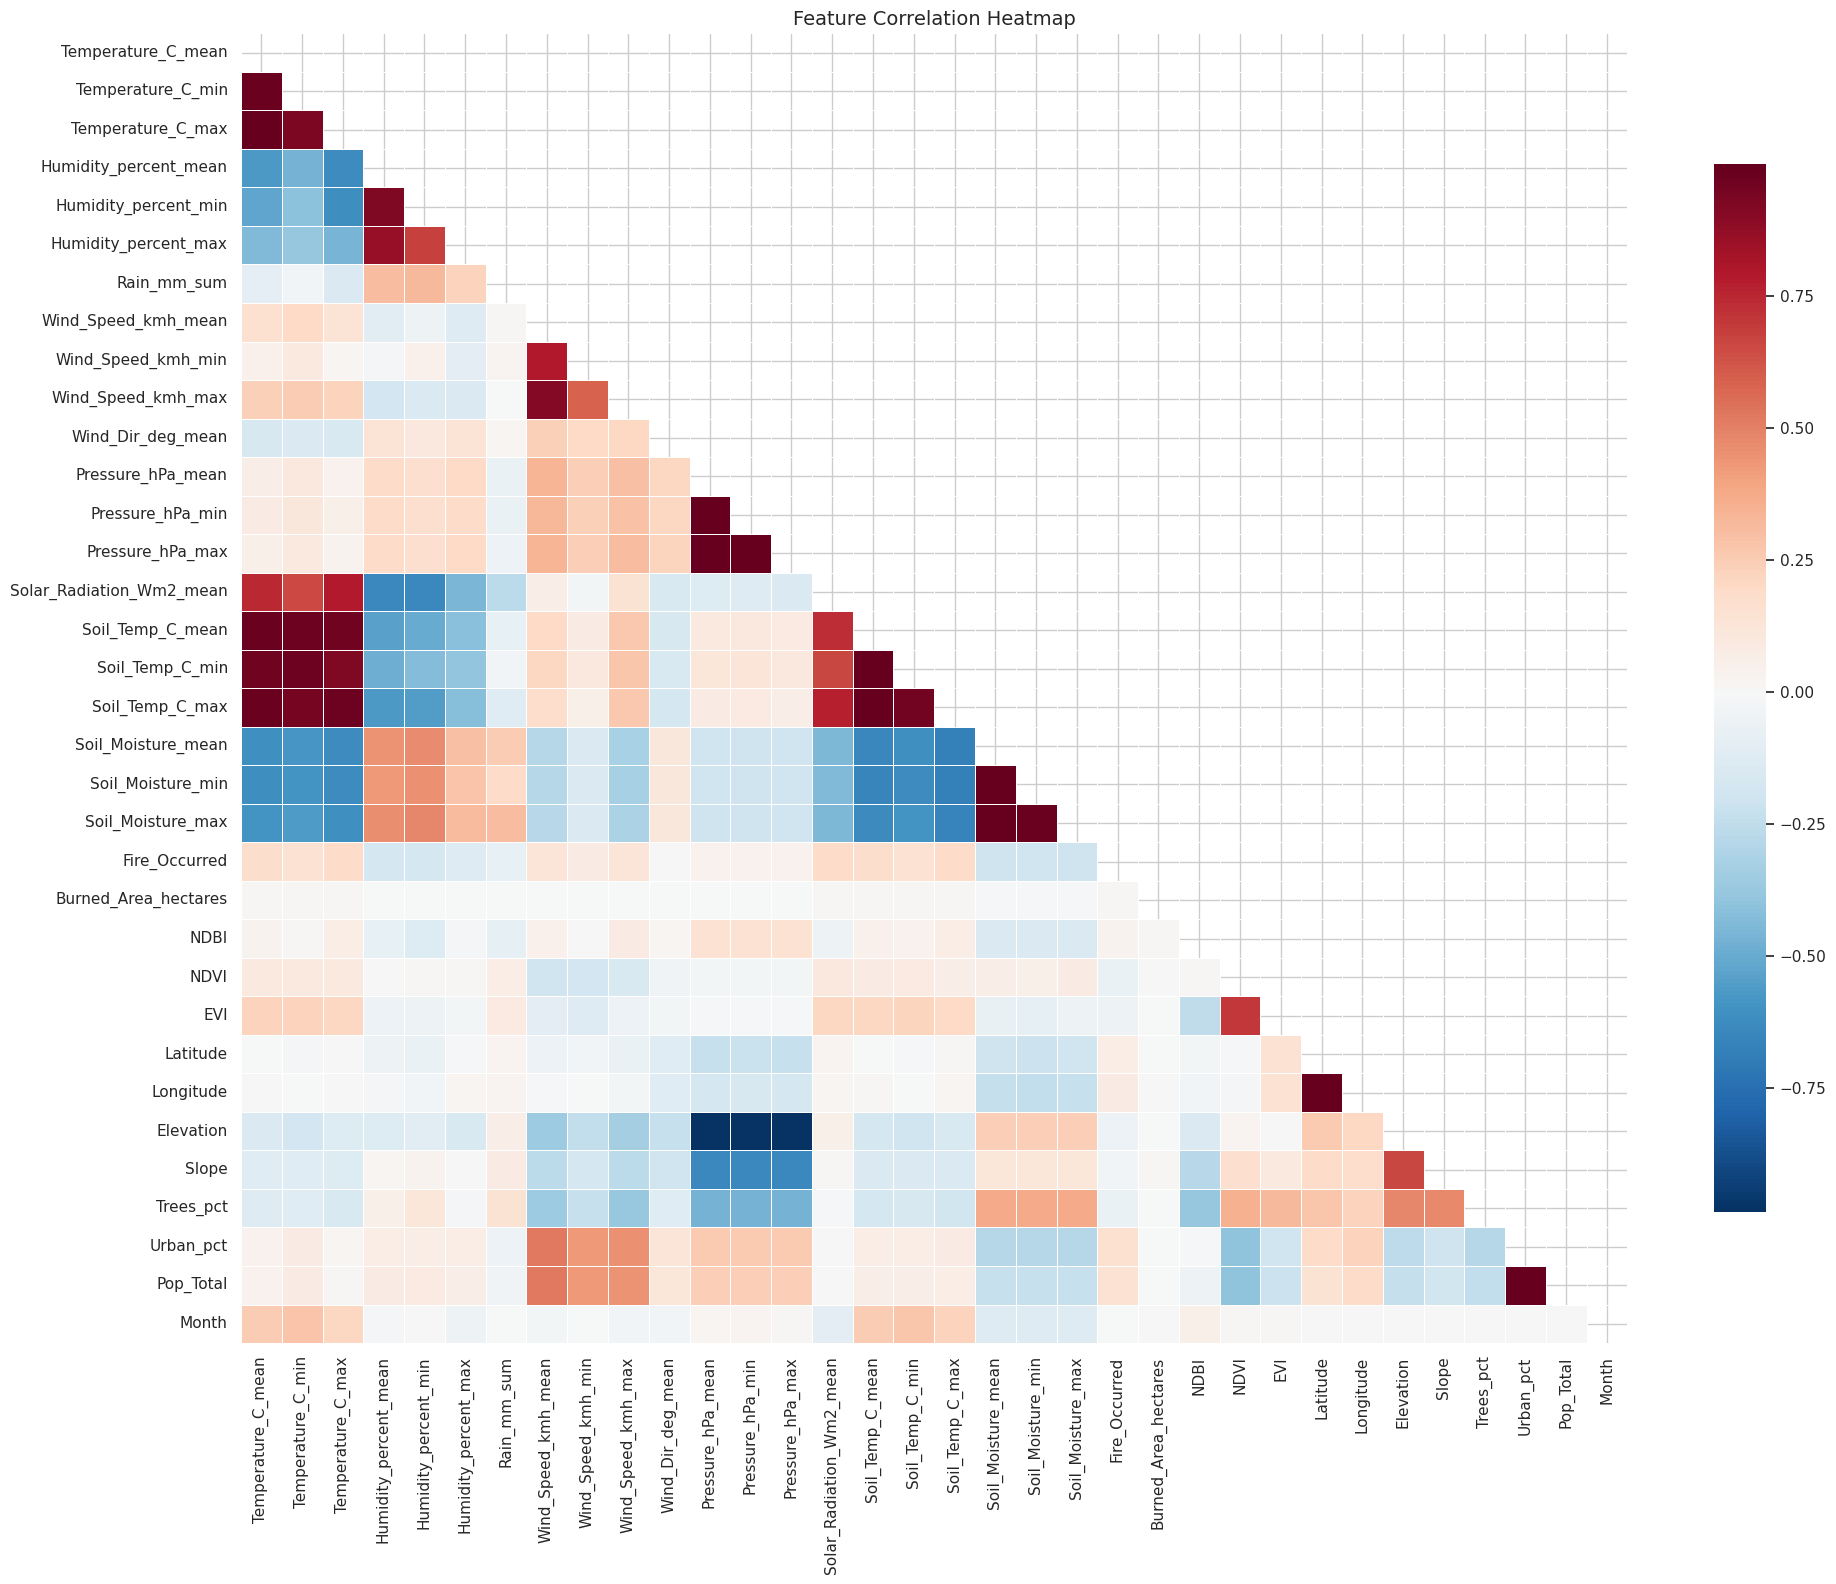

Top 20 features correlated with Fire_Occurred:
  Soil_Moisture_max                        -0.2074
  Soil_Moisture_mean                       -0.2042
  Soil_Moisture_min                        -0.1990
  Soil_Temp_C_max                          +0.1899
  Solar_Radiation_Wm2_mean                 +0.1894
  Temperature_C_max                        +0.1867
  Humidity_percent_min                     -0.1787
  Humidity_percent_mean                    -0.1759
  Temperature_C_mean                       +0.1741
  Soil_Temp_C_mean                         +0.1722
  Urban_pct                                +0.1556
  Temperature_C_min                        +0.1534
  Pop_Total                                +0.1514
  Soil_Temp_C_min                          +0.1503
  Wind_Speed_kmh_max                       +0.1284
  Wind_Speed_kmh_mean                      +0.1268
  Humidity_percent_max                     -0.1250
  Rain_mm_sum                              -0.0853
  Longitude                        

In [41]:
# ─── §5: Correlation analysis ─────────────────────────────────────────────
numeric_cols = df.select_dtypes(include="number").columns.tolist()
# Exclude calendar identifiers from correlation
corr_cols = [c for c in numeric_cols if c not in
             ["Year","DayOfYear","DayOfWeek","fire_count","mean_brightness","max_frp"]]

# 5a. Full correlation heatmap
corr_matrix = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap="RdBu_r", center=0,
            annot=False, fmt=".2f", ax=ax, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUTS / "correlation_heatmap.png", dpi=150)
plt.show()

# 5b. Correlation with Fire_Occurred
fire_corr = df[corr_cols].corr()["Fire_Occurred"].drop("Fire_Occurred").sort_values(
    key=abs, ascending=False)
print("Top 20 features correlated with Fire_Occurred:")
for feat, val in fire_corr.head(20).items():
    print(f"  {feat:40s} {val:+.4f}")

# 5c. Multicollinearity check (pairs with |r| > 0.9)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append((
                corr_matrix.columns[i], corr_matrix.columns[j],
                corr_matrix.iloc[i, j]))
print(f"\nHighly correlated pairs (|r| > 0.9): {len(high_corr_pairs)}")
for a, b, r in high_corr_pairs[:10]:
    print(f"  {a:35s} ↔ {b:35s}  r={r:.3f}")

Testing 14 variables across 16 cities
Hypothesis tests: 210 total, 201 significant (p < 0.05)
Significance rate: 95.7%

Most consistently significant variables:
  Humidity_percent_max                     significant in 100% of cities
  Humidity_percent_mean                    significant in 100% of cities
  Soil_Moisture_max                        significant in 100% of cities
  Rain_mm_sum                              significant in 100% of cities
  Soil_Temp_C_max                          significant in 100% of cities
  Soil_Moisture_mean                       significant in 100% of cities
  Temperature_C_max                        significant in 100% of cities
  Temperature_C_mean                       significant in 100% of cities
  Soil_Temp_C_mean                         significant in 100% of cities
  Solar_Radiation_Wm2_mean                 significant in 100% of cities
  Wind_Speed_kmh_max                       significant in 87% of cities
  Pressure_hPa_mean                  

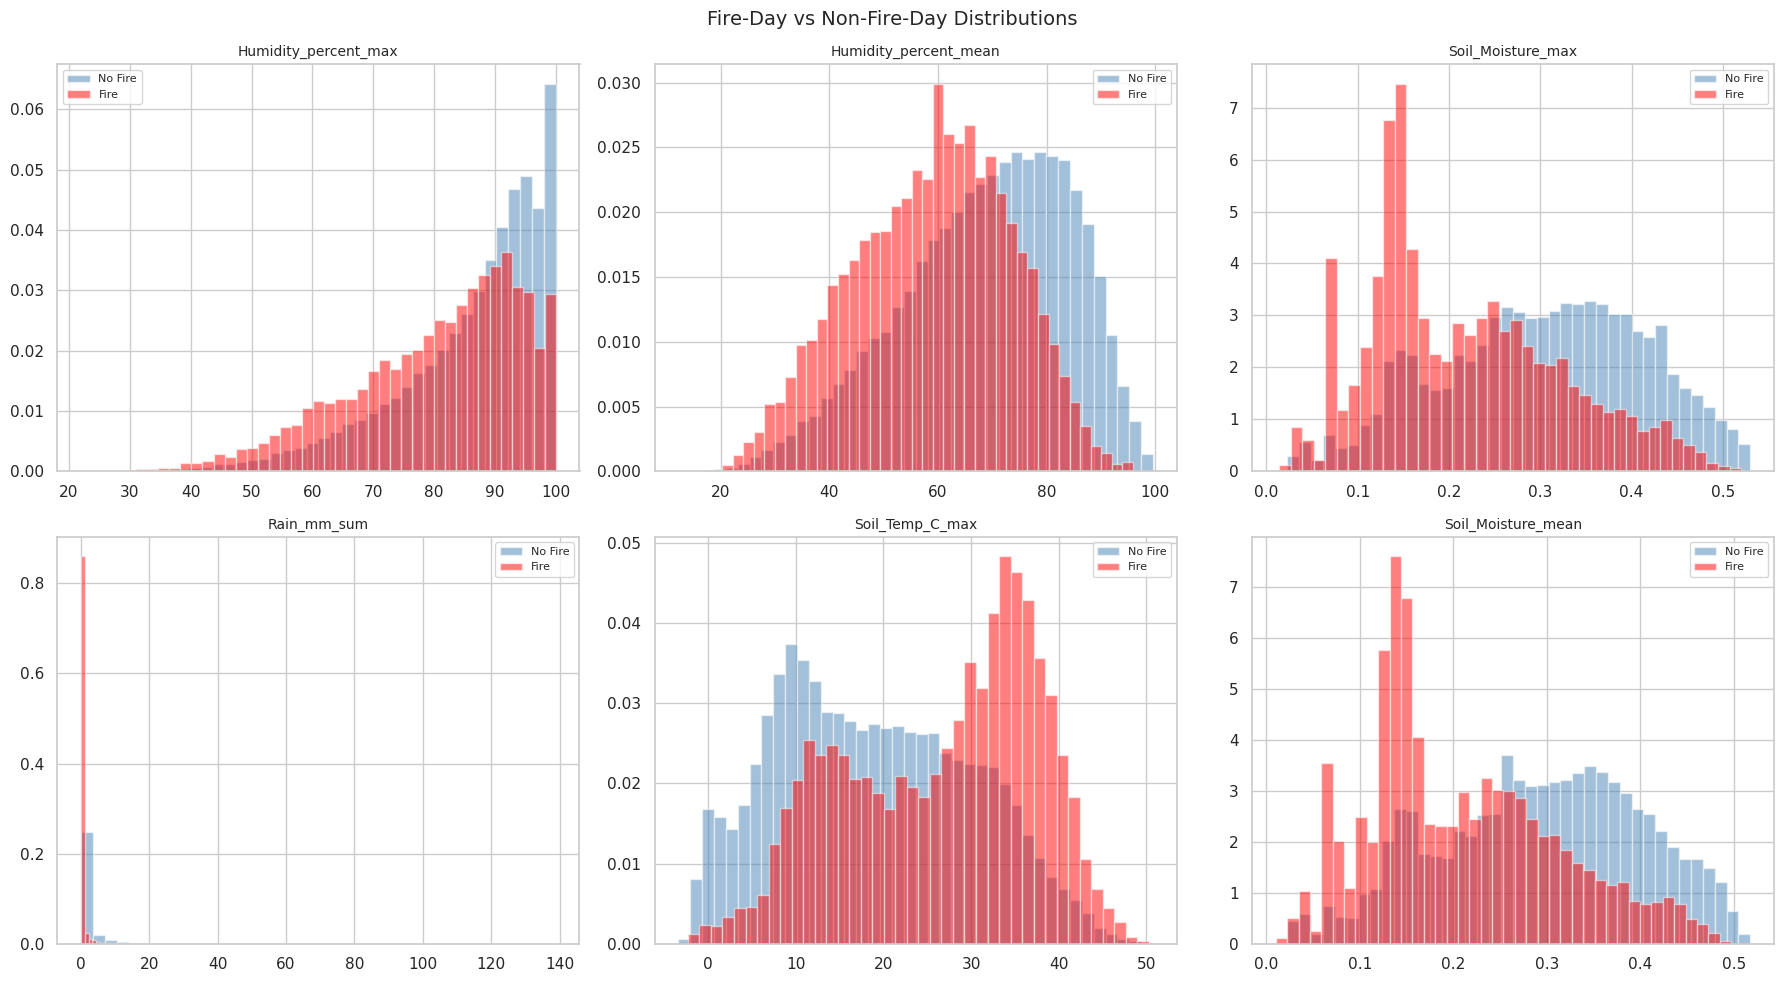

Hypothesis testing complete.


In [42]:
# ─── §6: Hypothesis testing — fire-day vs non-fire-day ────────────────────
# Welch's t-test for each weather variable × each city
# H0: mean(fire_day) = mean(non_fire_day)
# H1: mean(fire_day) ≠ mean(non_fire_day)

# Re-derive WEATHER_COLS in case cell order changes
if not WEATHER_COLS:
    WEATHER_COLS = [c for c in df.columns if any(k in c for k in
        ["Temperature","Humidity","Rain","Wind_Speed","Pressure",
         "Solar","Soil_Temp","Soil_Moisture"]) and pd.api.types.is_numeric_dtype(df[c])]

test_vars = [c for c in WEATHER_COLS if "_mean" in c or "_sum" in c or "_max" in c]
if not test_vars:
    # fallback: use all numeric weather-like columns
    test_vars = WEATHER_COLS
print(f"Testing {len(test_vars)} variables across {df['City'].nunique()} cities")

alpha = 0.05

results = []
for city in df["City"].unique():
    g = df[df["City"] == city]
    fire = g[g["Fire_Occurred"] == 1]
    no_fire = g[g["Fire_Occurred"] == 0]
    if len(fire) < 5:
        continue
    for var in test_vars:
        f_vals = fire[var].dropna()
        nf_vals = no_fire[var].dropna()
        if len(f_vals) < 3 or len(nf_vals) < 3:
            continue
        t_stat, p_val = stats.ttest_ind(f_vals, nf_vals, equal_var=False)
        results.append({
            "City": city, "Variable": var,
            "Fire_mean": f_vals.mean(), "NoFire_mean": nf_vals.mean(),
            "Diff": f_vals.mean() - nf_vals.mean(),
            "t_stat": t_stat, "p_value": p_val,
            "Significant": p_val < alpha,
        })

hyp_df = pd.DataFrame(results)

if hyp_df.empty:
    print("⚠ No hypothesis tests were run — check WEATHER_COLS and test_vars")
    print(f"  WEATHER_COLS: {WEATHER_COLS[:5]}")
    print(f"  test_vars: {test_vars[:5]}")
    sig_count, total = 0, 0
else:
    sig_count = hyp_df["Significant"].sum()
    total = len(hyp_df)
    print(f"Hypothesis tests: {total} total, {sig_count} significant (p < {alpha})")
    print(f"Significance rate: {sig_count/total*100:.1f}%")

    # Most significant variables across cities
    print("\nMost consistently significant variables:")
    var_sig = (hyp_df.groupby("Variable")["Significant"]
               .mean().sort_values(ascending=False))
    for var, rate in var_sig.head(15).items():
        print(f"  {var:40s} significant in {rate*100:.0f}% of cities")

    hyp_df.to_csv(OUTPUTS / "hypothesis_tests.csv", index=False)

    # Visualization: fire-day vs non-fire-day for top variables
    top_vars = var_sig.head(6).index.tolist()
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("Fire-Day vs Non-Fire-Day Distributions", fontsize=14)
    for ax, var in zip(axes.flat, top_vars):
        fire_data = df[df["Fire_Occurred"]==1][var]
        nofire_data = df[df["Fire_Occurred"]==0][var]
        ax.hist(nofire_data, bins=40, alpha=0.5, label="No Fire", color="steelblue", density=True)
        ax.hist(fire_data, bins=40, alpha=0.5, label="Fire", color="red", density=True)
        ax.set_title(var, fontsize=10)
        ax.legend(fontsize=8)
    for ax in axes.flat[len(top_vars):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.savefig(OUTPUTS / "fire_vs_nofire_distributions.png", dpi=150)
    plt.show()

print("Hypothesis testing complete.")

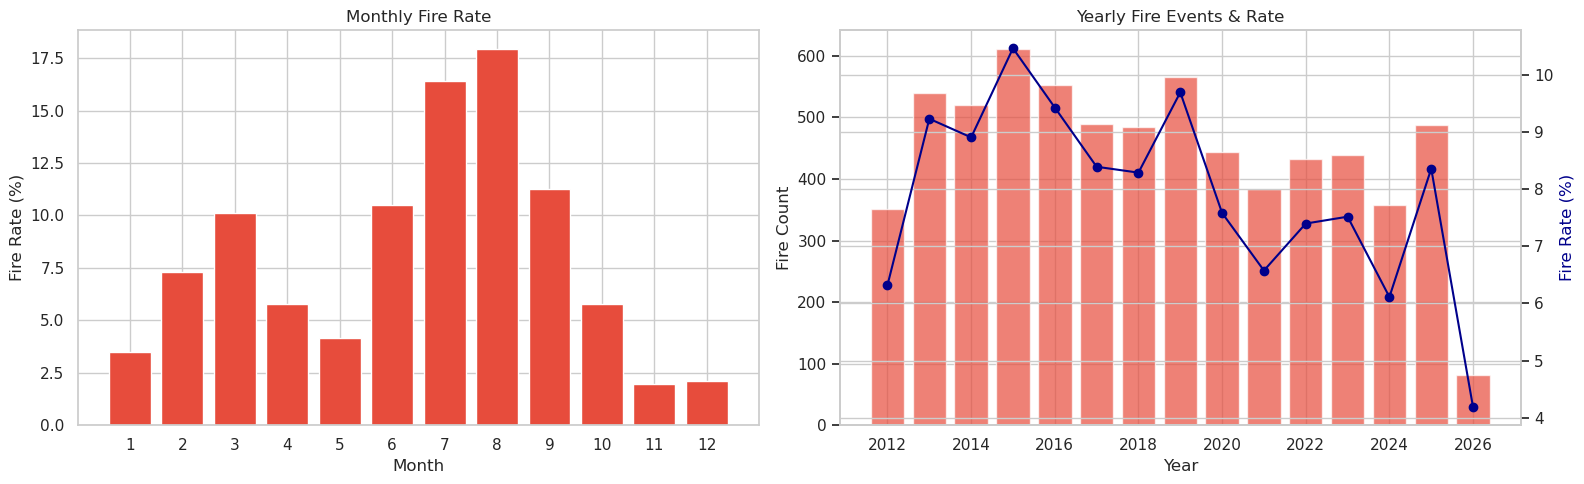

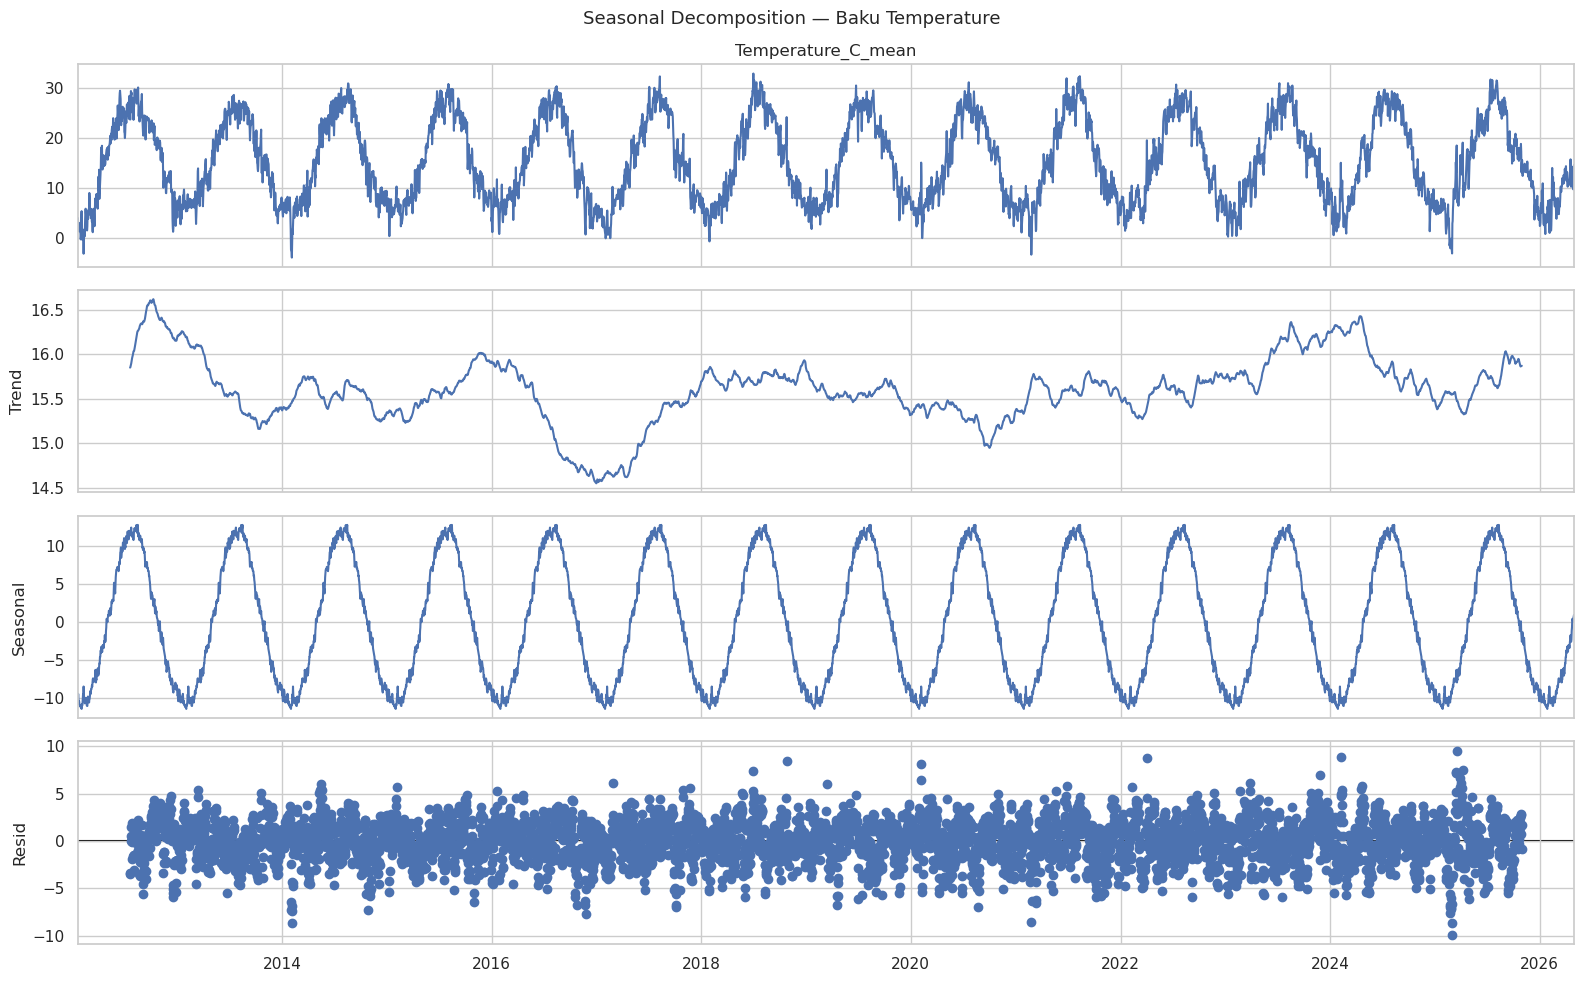

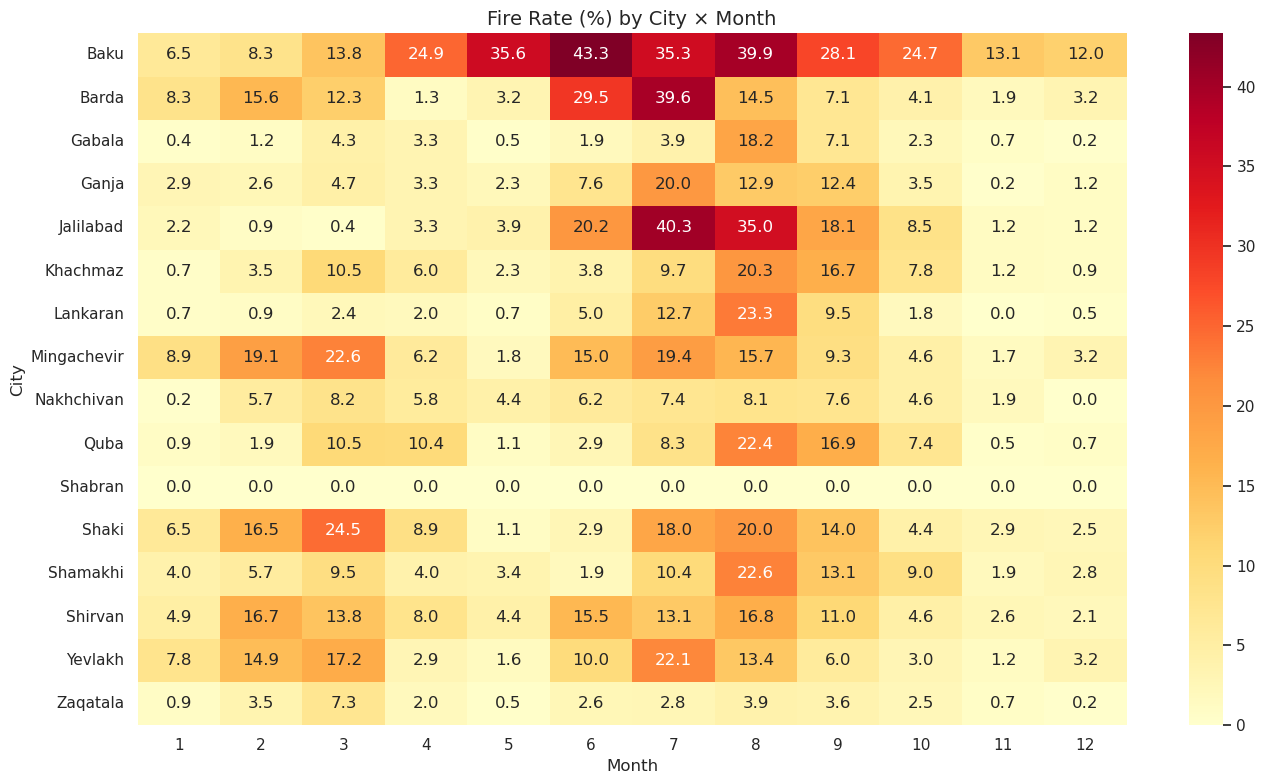

Seasonal analysis complete.


In [43]:
# ─── §7: Seasonal decomposition & time-series patterns ────────────────────

# 7a. Monthly fire rate
df["Month"] = df["Date"].dt.month
monthly_fire = df.groupby("Month")["Fire_Occurred"].mean() * 100
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(monthly_fire.index, monthly_fire.values, color="#e74c3c")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Fire Rate (%)")
axes[0].set_title("Monthly Fire Rate")
axes[0].set_xticks(range(1,13))

# 7b. Yearly fire trend
yearly_fire = df.groupby("Year")["Fire_Occurred"].agg(["sum","mean"])
yearly_fire["mean"] *= 100
axes[1].bar(yearly_fire.index, yearly_fire["sum"], alpha=0.7, color="#e74c3c")
ax2 = axes[1].twinx()
ax2.plot(yearly_fire.index, yearly_fire["mean"], "o-", color="darkblue")
ax2.set_ylabel("Fire Rate (%)", color="darkblue")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Fire Count")
axes[1].set_title("Yearly Fire Events & Rate")
plt.tight_layout()
plt.savefig(OUTPUTS / "seasonal_fire_patterns.png", dpi=150)
plt.show()

# 7c. Seasonal decomposition of temperature for Baku
if "Temperature_C_mean" in df.columns:
    baku = df[df["City"]=="Baku"].set_index("Date")["Temperature_C_mean"].dropna()
    if len(baku) > 365:
        decomp = seasonal_decompose(baku, model="additive", period=365)
        fig = decomp.plot()
        fig.set_size_inches(16, 10)
        fig.suptitle("Seasonal Decomposition — Baku Temperature", fontsize=13)
        plt.tight_layout()
        plt.savefig(OUTPUTS / "seasonal_decomposition.png", dpi=150)
        plt.show()

# 7d. Fire rate by city and month (heatmap)
pivot = df.pivot_table(values="Fire_Occurred", index="City",
                        columns="Month", aggfunc="mean") * 100
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax)
ax.set_title("Fire Rate (%) by City × Month", fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUTS / "fire_rate_city_month.png", dpi=150)
plt.show()
print("Seasonal analysis complete.")

In [44]:
# ─── §8: Outlier detection (IQR) & data cleaning ─────────────────────────

# Re-derive WEATHER_COLS if empty
if not WEATHER_COLS:
    WEATHER_COLS = [c for c in df.columns if any(k in c for k in
        ["Temperature","Humidity","Rain","Wind_Speed","Pressure",
         "Solar","Soil_Temp","Soil_Moisture"]) and pd.api.types.is_numeric_dtype(df[c])]

# 8a. IQR-based outlier detection per city per feature
outlier_counts = []
for city in df["City"].unique():
    g = df[df["City"]==city]
    for col in WEATHER_COLS:
        Q1 = g[col].quantile(0.25)
        Q3 = g[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_out = ((g[col] < lower) | (g[col] > upper)).sum()
        outlier_counts.append({"City": city, "Variable": col,
                                "Outliers": n_out, "Pct": n_out/len(g)*100})

outlier_df = pd.DataFrame(outlier_counts)
if not outlier_df.empty:
    print("Top 15 city-variable pairs by outlier %:")
    print(outlier_df.sort_values("Pct", ascending=False).head(15).to_string(index=False))
else:
    print("No outliers detected (WEATHER_COLS may be empty)")

# 8b. Winsorize extreme outliers (clip at 1st/99th percentile)
for col in WEATHER_COLS:
    p01 = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)
    df[col] = df[col].clip(p01, p99)

print(f"\nWinsorized {len(WEATHER_COLS)} columns at 1st/99th percentile")

# 8c. Fill remaining NaNs with per-city median
for col in df.select_dtypes(include="number").columns:
    if df[col].isnull().any():
        df[col] = df.groupby("City")[col].transform(
            lambda x: x.fillna(x.median()))

# Final NaN fill with 0
df = df.fillna(0)
print(f"Remaining NaNs: {df.isnull().sum().sum()}")
print(f"Clean data shape: {df.shape}")

Top 15 city-variable pairs by outlier %:
       City    Variable  Outliers       Pct
      Barda Rain_mm_sum      1068 20.471535
 Nakhchivan Rain_mm_sum      1055 20.222350
    Yevlakh Rain_mm_sum       996 19.091432
       Baku Rain_mm_sum       996 19.091432
Mingachevir Rain_mm_sum       984 18.861415
    Shirvan Rain_mm_sum       968 18.554725
    Shabran Rain_mm_sum       932 17.864673
  Jalilabad Rain_mm_sum       889 17.040445
   Khachmaz Rain_mm_sum       889 17.040445
      Shaki Rain_mm_sum       853 16.350393
   Zaqatala Rain_mm_sum       828 15.871190
      Ganja Rain_mm_sum       813 15.583669
   Shamakhi Rain_mm_sum       808 15.487828
   Lankaran Rain_mm_sum       781 14.970289
     Gabala Rain_mm_sum       722 13.839371

Winsorized 20 columns at 1st/99th percentile
Remaining NaNs: 0
Clean data shape: (83472, 42)


In [45]:
# ─── §9a: Feature engineering — FWI proxy indices ─────────────────────────
# Simplified Canadian FWI system components

def engineer_fwi(group):
    """Compute Fire Weather Index proxy for one city's time series."""
    g = group.sort_values("Date").copy()

    T = g.get("Temperature_C_mean", pd.Series(0, index=g.index))
    H = g.get("Humidity_percent_mean", pd.Series(50, index=g.index))
    W = g.get("Wind_Speed_kmh_mean", pd.Series(0, index=g.index))
    R = g.get("Rain_mm_sum", pd.Series(0, index=g.index))

    # Fine Fuel Moisture Code (simplified)
    g["FFMC_proxy"] = 100 - (H * 0.5 + R.clip(0, 10) * 3 - T.clip(0, 40) * 0.5)
    g["FFMC_proxy"] = g["FFMC_proxy"].clip(0, 100)

    # Duff Moisture Code (simplified — cumulative drying)
    g["DMC_proxy"] = (T.clip(0) * 0.3 - R * 0.8 + (100 - H) * 0.1)
    g["DMC_proxy"] = g["DMC_proxy"].rolling(14, min_periods=1).mean().clip(0)

    # Drought Code (simplified — long-term drying)
    g["DC_proxy"] = (T.clip(0) * 0.2 - R * 0.5).rolling(30, min_periods=1).sum().clip(0)

    # Initial Spread Index
    g["ISI_proxy"] = (g["FFMC_proxy"] / 100) * (W * 0.3)

    # Build-Up Index
    g["BUI_proxy"] = (g["DMC_proxy"] + g["DC_proxy"]) / 2

    # Fire Weather Index (combined)
    g["FWI_proxy"] = g["ISI_proxy"] * g["BUI_proxy"] / 50
    g["FWI_proxy"] = g["FWI_proxy"].clip(0)

    return g

print("Computing FWI proxy indices...")
parts = []
for city in tqdm(df["City"].unique(), desc="FWI"):
    parts.append(engineer_fwi(df[df["City"]==city]))
df = pd.concat(parts, ignore_index=True)
print(f"FWI columns added: FFMC_proxy, DMC_proxy, DC_proxy, ISI_proxy, BUI_proxy, FWI_proxy")

Computing FWI proxy indices...


FWI:   0%|          | 0/16 [00:00<?, ?it/s]

FWI columns added: FFMC_proxy, DMC_proxy, DC_proxy, ISI_proxy, BUI_proxy, FWI_proxy


In [46]:
# ─── §9b: Feature engineering — lag & rolling features ────────────────────

LAG_DAYS = [1, 2, 3, 5, 7, 14, 30]
ROLLING_WINDOWS = [3, 7, 14, 30]

LAG_VARS = [c for c in ["Temperature_C_mean","Temperature_C_max",
             "Humidity_percent_mean","Humidity_percent_min",
             "Wind_Speed_kmh_mean","Wind_Speed_kmh_max",
             "Rain_mm_sum","Solar_Radiation_Wm2_mean",
             "Soil_Temp_C_mean","Soil_Moisture_mean",
             "FWI_proxy"] if c in df.columns]

def build_lag_rolling(group):
    g = group.sort_values("Date").copy()
    for var in LAG_VARS:
        for lag in LAG_DAYS:
            g[f"{var}_lag{lag}"] = g[var].shift(lag)
        for w in ROLLING_WINDOWS:
            rolled = g[var].shift(1).rolling(w, min_periods=1)
            g[f"{var}_roll{w}_mean"] = rolled.mean()
            g[f"{var}_roll{w}_std"]  = rolled.std()

    # Dry-day streak
    if "Rain_mm_sum" in g.columns:
        is_dry = (g["Rain_mm_sum"] < 0.1).astype(int)
        dry_groups = is_dry.ne(is_dry.shift()).cumsum()
        g["dry_days_streak"] = is_dry.groupby(dry_groups).cumsum()

    # Temperature range
    if "Temperature_C_max" in g.columns and "Temperature_C_min" in g.columns:
        g["temp_range"] = g["Temperature_C_max"] - g["Temperature_C_min"]

    return g

print("Building lag & rolling features...")
parts = []
for city in tqdm(df["City"].unique(), desc="Lag/Roll"):
    parts.append(build_lag_rolling(df[df["City"]==city]))
df = pd.concat(parts, ignore_index=True)

new_cols = [c for c in df.columns if "lag" in c or "roll" in c or c in
            ["dry_days_streak","temp_range"]]
print(f"New lag/rolling features: {len(new_cols)}")

Building lag & rolling features...


Lag/Roll:   0%|          | 0/16 [00:00<?, ?it/s]

New lag/rolling features: 167


In [47]:
# ─── §9c: Feature engineering — Prophet weather residuals (optional) ──────
# Prophet captures seasonality; the residual = anomalous weather = fire risk signal

try:
    from prophet import Prophet
    PROPHET_OK = True
except ImportError:
    PROPHET_OK = False
    print("Prophet not installed — skipping residual features")

PROPHET_TARGETS = [c for c in ["Temperature_C_mean","Humidity_percent_mean",
                    "Rain_mm_sum","Wind_Speed_kmh_mean"] if c in df.columns]

PROPHET_CACHE = MODELS / "prophet_cache"
PROPHET_CACHE.mkdir(exist_ok=True)

if PROPHET_OK and len(PROPHET_TARGETS) > 0:
    print(f"Fitting Prophet for {len(PROPHET_TARGETS)} vars × {df['City'].nunique()} cities...")

    for city in tqdm(df["City"].unique(), desc="Prophet"):
        mask = df["City"] == city
        city_data = df[mask].copy()

        for var in PROPHET_TARGETS:
            cache_key = f"{city.replace(' ','_')}_{var}"
            cache_path = PROPHET_CACHE / f"{cache_key}.pkl"

            sub = city_data[["Date", var]].dropna().rename(
                columns={"Date": "ds", var: "y"})
            if len(sub) < 60:
                continue

            # Load or fit
            if cache_path.exists():
                with open(cache_path, "rb") as f:
                    m = pickle.load(f)
            else:
                m = Prophet(yearly_seasonality=True, weekly_seasonality=True,
                            daily_seasonality=False, changepoint_prior_scale=0.05,
                            seasonality_mode="multiplicative" if "Rain" in var else "additive")
                m.fit(sub)
                with open(cache_path, "wb") as f:
                    pickle.dump(m, f)

            future = city_data[["Date"]].rename(columns={"Date": "ds"})
            forecast = m.predict(future)
            df.loc[mask, f"prophet_{var}_pred"]  = forecast["yhat"].values
            df.loc[mask, f"prophet_{var}_resid"] = (
                city_data[var].values - forecast["yhat"].values)

    prophet_cols = [c for c in df.columns if "prophet_" in c]
    print(f"Prophet features added: {len(prophet_cols)}")
else:
    print("Skipping Prophet residuals")

Fitting Prophet for 4 vars × 16 cities...


Prophet:   0%|          | 0/16 [00:00<?, ?it/s]

Prophet features added: 8


In [48]:
# ─── §9d: Cyclical calendar encodings ─────────────────────────────────────
df["Month_sin"]  = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"]  = np.cos(2 * np.pi * df["Month"] / 12)
df["DoY_sin"]    = np.sin(2 * np.pi * df["DayOfYear"] / 365)
df["DoY_cos"]    = np.cos(2 * np.pi * df["DayOfYear"] / 365)
df["DoW_sin"]    = np.sin(2 * np.pi * df["DayOfWeek"] / 7)
df["DoW_cos"]    = np.cos(2 * np.pi * df["DayOfWeek"] / 7)

# Season flag
df["is_summer"]  = df["Month"].isin([6,7,8]).astype(int)
df["is_fire_season"] = df["Month"].isin([5,6,7,8,9]).astype(int)

print("Calendar features added: Month_sin/cos, DoY_sin/cos, DoW_sin/cos, is_summer, is_fire_season")

Calendar features added: Month_sin/cos, DoY_sin/cos, DoW_sin/cos, is_summer, is_fire_season


In [49]:
# ─── §9h: Hourly feature engineering — hour-derived daily aggregates ──────
# Extract intra-day patterns as daily features:
# - Diurnal temp range (max_hour - min_hour)
# - Hours above fire-risk thresholds
# - Peak hour stats (solar peak, wind gust hour, etc.)
# Also applies FWI, lag/rolling and calendar features to hourly data.

if HAS_HOURLY:
    print("=" * 60)
    print("HOURLY FEATURE ENGINEERING")
    print("=" * 60)

    # A) Extract hour-derived features and merge into daily df
    print("Extracting hourly-derived daily features...")
    h_feats = []
    for city in tqdm(df_h["City"].unique(), desc="Hourly→Daily FE"):
        ch = df_h[df_h["City"] == city].copy()

        daily_agg = ch.groupby("Date").agg(
            **{
                # Diurnal ranges
                **({f"{v}_diurnal_range": (v, lambda x: x.max() - x.min())
                    for v in ["Temperature_C", "Humidity_percent"]
                    if v in ch.columns}),
                # Hours above fire-risk thresholds
                **({"hours_temp_above_30": ("Temperature_C",
                     lambda x: (x > 30).sum())} if "Temperature_C" in ch.columns else {}),
                **({"hours_humidity_below_30": ("Humidity_percent",
                     lambda x: (x < 30).sum())} if "Humidity_percent" in ch.columns else {}),
                **({"hours_wind_above_20": ("Wind_Speed_kmh",
                     lambda x: (x > 20).sum())} if "Wind_Speed_kmh" in ch.columns else {}),
                # Peak hour of solar radiation
                **({"solar_peak_hour": ("Solar_Radiation_Wm2",
                     lambda x: x.idxmax())} if "Solar_Radiation_Wm2" in ch.columns else {}),
                # Night-time minimum temperature (00:00-06:00)
                **({"temp_night_min": ("Temperature_C",
                     lambda x: x.iloc[:6].min() if len(x) >= 6 else x.min()
                    )} if "Temperature_C" in ch.columns else {}),
                # Afternoon max temperature (12:00-18:00)
                **({"temp_afternoon_max": ("Temperature_C",
                     lambda x: x.iloc[12:18].max() if len(x) >= 18 else x.max()
                    )} if "Temperature_C" in ch.columns else {}),
            }
        ).reset_index()
        daily_agg["City"] = city
        h_feats.append(daily_agg)

    h_feats_df = pd.concat(h_feats, ignore_index=True)
    # Fix solar_peak_hour to actual hour number
    if "solar_peak_hour" in h_feats_df.columns:
        h_feats_df["solar_peak_hour"] = pd.to_numeric(
            h_feats_df["solar_peak_hour"], errors="coerce").fillna(12)

    # Merge hourly-derived features into daily
    df = df.merge(h_feats_df, on=["City", "Date"], how="left")
    df = df.fillna(0)

    hourly_derived = [c for c in h_feats_df.columns if c not in ["City", "Date"]]
    print(f"Hourly-derived daily features added: {len(hourly_derived)}")
    for c in hourly_derived:
        print(f"  {c}")

    # B) Apply FWI, lag/rolling to hourly dataset too
    print("\nApplying lag/rolling to hourly data...")

    HOURLY_LAG_VARS = [c for c in ["Temperature_C", "Humidity_percent",
                        "Wind_Speed_kmh", "Rain_mm", "Solar_Radiation_Wm2"]
                       if c in df_h.columns]
    HOURLY_LAGS = [1, 3, 6, 12, 24]
    HOURLY_ROLLS = [6, 12, 24]

    parts_h = []
    for city in tqdm(df_h["City"].unique(), desc="Hourly Lag/Roll"):
        g = df_h[df_h["City"] == city].sort_values("Timestamp").copy()
        for var in HOURLY_LAG_VARS:
            for lag in HOURLY_LAGS:
                g[f"{var}_lag{lag}h"] = g[var].shift(lag)
            for w in HOURLY_ROLLS:
                rolled = g[var].shift(1).rolling(w, min_periods=1)
                g[f"{var}_roll{w}h_mean"] = rolled.mean()
                g[f"{var}_roll{w}h_std"] = rolled.std()
        parts_h.append(g)

    df_h = pd.concat(parts_h, ignore_index=True)

    # Hourly cyclical features
    df_h["Hour_sin"] = np.sin(2 * np.pi * df_h["Hour"] / 24)
    df_h["Hour_cos"] = np.cos(2 * np.pi * df_h["Hour"] / 24)
    df_h["Month_sin"] = np.sin(2 * np.pi * df_h["Month"] / 12)
    df_h["Month_cos"] = np.cos(2 * np.pi * df_h["Month"] / 12)
    df_h["DoY_sin"] = np.sin(2 * np.pi * df_h["DayOfYear"] / 365)
    df_h["DoY_cos"] = np.cos(2 * np.pi * df_h["DayOfYear"] / 365)
    df_h["DoW_sin"] = np.sin(2 * np.pi * df_h["DayOfWeek"] / 7)
    df_h["DoW_cos"] = np.cos(2 * np.pi * df_h["DayOfWeek"] / 7)
    df_h["is_fire_season"] = df_h["Month"].isin([5, 6, 7, 8, 9]).astype(int)
    df_h["is_daytime"] = df_h["Hour"].between(6, 18).astype(int)

    hourly_new = [c for c in df_h.columns if "lag" in c or "roll" in c or
                  c in ["Hour_sin", "Hour_cos", "is_daytime"]]
    print(f"Hourly lag/rolling/calendar features: {len(hourly_new)}")
    df_h = df_h.fillna(0)
    print(f"Hourly engineered shape: {df_h.shape}")

else:
    print("Skipping hourly FE — no hourly data available")

HOURLY FEATURE ENGINEERING
Extracting hourly-derived daily features...


Hourly→Daily FE:   0%|          | 0/16 [00:00<?, ?it/s]

Hourly-derived daily features added: 8
  Temperature_C_diurnal_range
  Humidity_percent_diurnal_range
  hours_temp_above_30
  hours_humidity_below_30
  hours_wind_above_20
  solar_peak_hour
  temp_night_min
  temp_afternoon_max

Applying lag/rolling to hourly data...


Hourly Lag/Roll:   0%|          | 0/16 [00:00<?, ?it/s]

Hourly lag/rolling/calendar features: 58
Hourly engineered shape: (2002944, 97)


### §9e — Wildfire-Specific Features

Add meteorological indices and interaction features that are **directly linked to fire ignition and spread**:
- **VPD (Vapor Pressure Deficit):** drier air = more evaporation = drier fuel
- **Dew Point:** low dew point = dry conditions
- **Heat Index:** perceived temperature — extreme values stress vegetation
- **Drought proxy:** 30-day rainfall deficit from monthly normal
- **Extreme weather flags:** heatwave, low humidity, high wind, dry spell
- **Interaction features:** temperature × low humidity, dry days × wind — these capture the *combined* effect
- **Historical fire features:** days since last fire, rolling fire counts — fire begets fire (carry-over ignition sources)

In [50]:
# ─── §9e: Wildfire-specific features ──────────────────────────────────────
# Uses reusable functions from src/features.py

import sys as _sys
from pathlib import Path as _Path
_sys.path.insert(0, str(_Path.cwd().parent if _Path.cwd().name == "notebooks" else _Path.cwd()))

from src.features import (compute_vpd, compute_dew_point, compute_heat_index,
                           add_wildfire_weather_features, add_historical_fire_features,
                           add_vegetation_interactions, add_anomaly_features)

print("=" * 60)
print("§9e: WILDFIRE-SPECIFIC FEATURE ENGINEERING")
print("=" * 60)

# ── 1. VPD, Dew Point, Heat Index, Drought, Extreme Flags, Interactions ──
df = add_wildfire_weather_features(df)
new_weather = [c for c in df.columns if c in [
    "VPD_kPa", "Dew_Point_C", "Heat_Index", "Rain_roll30_sum",
    "Rainfall_Deficit", "dry_days_streak", "heatwave_flag",
    "low_humidity_flag", "high_wind_flag", "dry_spell_flag",
    "temp_x_low_hum", "temp_x_wind", "dry_days_x_wind", "hot_dry_windy"]]
print(f"\nWeather-fire features added: {len(new_weather)}")
for c in new_weather:
    print(f"  {c:30s}  mean={df[c].mean():.4f}  std={df[c].std():.4f}")

# ── 2. Historical fire features (strictly lagged to prevent leakage) ─────
df = add_historical_fire_features(df)
fire_hist_cols = [c for c in df.columns if c.startswith("fire_count_") or
                  c in ["days_since_last_fire", "city_month_fire_rate", "city_fire_rate"]]
print(f"\nHistorical fire features added: {len(fire_hist_cols)}")
for c in fire_hist_cols:
    print(f"  {c:30s}  mean={df[c].mean():.4f}")

# ── 3. Vegetation × weather interactions ─────────────────────────────────
df = add_vegetation_interactions(df)
veg_int_cols = [c for c in df.columns if c in [
    "NDVI_x_drought", "forest_x_dry_days", "NDVI_x_VPD"]]
print(f"\nVegetation interaction features: {len(veg_int_cols)}")
for c in veg_int_cols:
    print(f"  {c:30s}  mean={df[c].mean():.4f}")

# ── 4. Anomaly features ──────────────────────────────────────────────────
df = add_anomaly_features(df, variables=[
    "Temperature_C_mean", "Humidity_percent_mean", "Rain_mm_sum",
    "Wind_Speed_kmh_mean", "Solar_Radiation_Wm2_mean"])
anomaly_cols = [c for c in df.columns if "_anomaly" in c]
print(f"\nAnomaly features: {len(anomaly_cols)}")
for c in anomaly_cols:
    print(f"  {c:30s}  mean={df[c].mean():.4f}")

# ── Summary ───────────────────────────────────────────────────────────────
all_new = new_weather + fire_hist_cols + veg_int_cols + anomaly_cols
print(f"\n{'='*60}")
print(f"Total new wildfire features: {len(all_new)}")
print(f"Dataset shape: {df.shape}")
print(f"{'='*60}")

# Quick correlation check with Fire_Occurred
print("\nCorrelation of new features with Fire_Occurred:")
fire_corr_new = df[all_new + ["Fire_Occurred"]].corr()["Fire_Occurred"].drop(
    "Fire_Occurred").sort_values(key=abs, ascending=False)
for feat, val in fire_corr_new.head(15).items():
    print(f"  {feat:35s} {val:+.4f}")

§9e: WILDFIRE-SPECIFIC FEATURE ENGINEERING

Weather-fire features added: 14
  dry_days_streak                 mean=3.1538  std=5.3113
  VPD_kPa                         mean=0.7070  std=0.6806
  Dew_Point_C                     mean=8.0083  std=7.2495
  Heat_Index                      mean=14.3755  std=9.2078
  Rain_roll30_sum                 mean=42.8157  std=36.7141
  Rainfall_Deficit                mean=0.2066  std=27.8284
  heatwave_flag                   mean=0.0500  std=0.2180
  low_humidity_flag               mean=0.1000  std=0.3000
  high_wind_flag                  mean=0.1000  std=0.3000
  dry_spell_flag                  mean=0.1495  std=0.3565
  temp_x_low_hum                  mean=5.3768  std=5.1862
  temp_x_wind                     mean=1.2458  std=1.1295
  dry_days_x_wind                 mean=0.2814  std=0.6358
  hot_dry_windy                   mean=0.0049  std=0.0700

Historical fire features added: 7
  fire_count_7d                   mean=0.5653
  fire_count_14d           

In [51]:
# ─── §10: Save BOTH engineered datasets ───────────────────────────────────
df = df.fillna(0)
df = df.sort_values(["City", "Date"]).reset_index(drop=True)

out_daily = PROCESSED / "engineered_daily.parquet"
df.to_parquet(out_daily, index=False)

print("=" * 60)
print("ENGINEERED DATASET SUMMARY")
print("=" * 60)

print(f"\n{'─'*30} DAILY {'─'*30}")
print(f"Shape          : {df.shape}")
print(f"Total features : {df.shape[1]}")
print(f"Saved to       : {out_daily}")
print(f"Size           : {out_daily.stat().st_size / 1e6:.1f} MB")

fwi_cols = [c for c in df.columns if "proxy" in c.lower() or "fwi" in c.lower()]
lag_cols = [c for c in df.columns if "lag" in c]
roll_cols = [c for c in df.columns if "roll" in c]
prophet_cols = [c for c in df.columns if "prophet_" in c]
cal_cols = [c for c in df.columns if c in
            ["Month_sin", "Month_cos", "DoY_sin", "DoY_cos",
             "DoW_sin", "DoW_cos", "is_summer", "is_fire_season"]]
hourly_derived = [c for c in df.columns if c in
    ["Temperature_C_diurnal_range", "Humidity_percent_diurnal_range",
     "hours_temp_above_30", "hours_humidity_below_30", "hours_wind_above_20",
     "solar_peak_hour", "temp_night_min", "temp_afternoon_max"]]

print(f"\nFeature groups:")
print(f"  FWI proxies       : {len(fwi_cols)}")
print(f"  Lag features      : {len(lag_cols)}")
print(f"  Rolling stats     : {len(roll_cols)}")
print(f"  Prophet resid     : {len(prophet_cols)}")
print(f"  Calendar          : {len(cal_cols)}")
print(f"  Hourly-derived    : {len(hourly_derived)}")
print(f"\nFire rate: {df['Fire_Occurred'].mean()*100:.2f}%")

# Save hourly
if HAS_HOURLY:
    df_h = df_h.fillna(0)
    df_h = df_h.sort_values(["City", "Timestamp"]).reset_index(drop=True)
    out_hourly = PROCESSED / "engineered_hourly.parquet"
    df_h.to_parquet(out_hourly, index=False)

    print(f"\n{'─'*30} HOURLY {'─'*29}")
    print(f"Shape          : {df_h.shape}")
    print(f"Total features : {df_h.shape[1]}")
    print(f"Saved to       : {out_hourly}")
    print(f"Size           : {out_hourly.stat().st_size / 1e6:.1f} MB")

    h_lag = [c for c in df_h.columns if "lag" in c]
    h_roll = [c for c in df_h.columns if "roll" in c]
    h_cal = [c for c in df_h.columns if c in
             ["Hour_sin", "Hour_cos", "Month_sin", "Month_cos",
              "DoY_sin", "DoY_cos", "DoW_sin", "DoW_cos",
              "is_fire_season", "is_daytime"]]
    print(f"\n  Hourly lag features  : {len(h_lag)}")
    print(f"  Hourly rolling stats : {len(h_roll)}")
    print(f"  Hourly calendar      : {len(h_cal)}")

print("\n→ Next: open 03_Weather_TimeSeries.ipynb")

ENGINEERED DATASET SUMMARY

────────────────────────────── DAILY ──────────────────────────────
Shape          : (83472, 267)
Total features : 267
Saved to       : /home/manheim666/Desktop/WildFire-Prediction/data/processed/engineered_daily.parquet
Size           : 127.1 MB

Feature groups:
  FWI proxies       : 21
  Lag features      : 81
  Rolling stats     : 89
  Prophet resid     : 8
  Calendar          : 8
  Hourly-derived    : 8

Fire rate: 8.07%

────────────────────────────── HOURLY ─────────────────────────────
Shape          : (2002944, 97)
Total features : 97
Saved to       : /home/manheim666/Desktop/WildFire-Prediction/data/processed/engineered_hourly.parquet
Size           : 447.9 MB

  Hourly lag features  : 25
  Hourly rolling stats : 30
  Hourly calendar      : 10

→ Next: open 03_Weather_TimeSeries.ipynb
